## Dataset Overview

* The dataset contains **9,800 sales records** from a retail superstore in the United States.
* It includes information about orders, customers, products, shipping details, regions, categories, and sales.
* During the data cleaning process, missing values in the **Postal Code** column were handled by removing the column, as it was not required for the analysis.
* The **Order Date** and **Ship Date** columns were converted to datetime format, and additional features (**Year**, **Month**, and **Month No**) were created for time-based analysis.
* The dataset is clean and ready for exploratory data analysis (EDA) to identify sales trends, customer behavior, product performance, and regional sales patterns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\HP\Documents\train.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.shape

(9800, 18)

In [4]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [6]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
df.nunique()

Row ID           9800
Order ID         4922
Order Date       1230
Ship Date        1326
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              529
State              49
Postal Code       626
Region              4
Product ID       1861
Category            3
Sub-Category       17
Product Name     1849
Sales            5757
dtype: int64

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

# Cleaning and Filtering the Data

In [9]:
# Find missing value
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df_clean = df.copy()

In [12]:
df_clean = df_clean.drop(columns="Postal Code")

In [13]:
print(type(df_clean))

<class 'pandas.DataFrame'>


In [14]:
df_clean.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [15]:
df_clean.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales'],
      dtype='str')

# Expolatry DAta Analysis

In [16]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Region         9800 non-null   str    
 12  Product ID     9800 non-null   str    
 13  Category       9800 non-null   str    
 14  Sub-Category   9800 non-null   str    
 15  Product Name   9800 non-null   str    
 16  Sales          9800 non-null   float64
dtypes: float64(1), int64(1), str(15)
memory usage: 1.3 MB


In [18]:
df_clean["Order Date"] = pd.to_datetime(
    df_clean["Order Date"],
    format="%d/%m/%Y"
)

df_clean["Ship Date"] = pd.to_datetime(
    df_clean["Ship Date"],
    format="%d/%m/%Y"
)

In [19]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Region         9800 non-null   str           
 12  Product ID     9800 non-null   str           
 13  Category       9800 non-null   str           
 14  Sub-Category   9800 non-null   str           
 15  Product Name   9800 non-null   s

In [20]:
df_clean["Year"] = df_clean["Order Date"].dt.year
df_clean["Month"] = df_clean["Order Date"].dt.month_name()
df_clean["Month No"] = df_clean["Order Date"].dt.month

In [21]:
df_clean.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month No
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,November,11
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,November,11
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,June,6
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,October,10
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,October,10


In [22]:
df_clean.describe()

,Row ID,Order Date,Ship Date,Sales,Year,Month No
count,9800.000000,9800,9800,9800.000000,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469,2017-05-05 04:17:52.653061,230.769059,2016.724184,7.818469
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,0.444000,2015.000000,1.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,17.248000,2016.000000,5.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,54.490000,2017.000000,9.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,210.605000,2018.000000,11.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,22638.480000,2018.000000,12.000000
std,2829.160653,NaN,NaN,626.651875,1.123984,3.281905


# Histplot

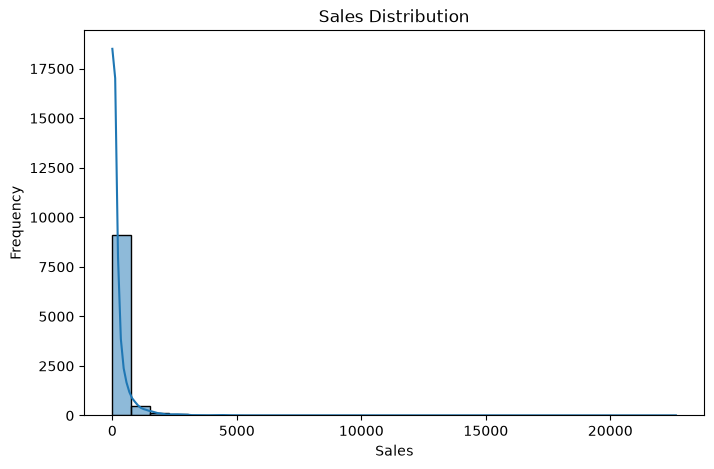

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["Sales"], bins=30, kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

### Observations

* Most sales transactions are concentrated at lower sales values.
* The sales distribution is **positively (right) skewed**, with a long tail toward higher sales values.
* A small number of transactions have very high sales amounts, while the majority of orders are relatively low in value.
* The distribution suggests the presence of high-value sales that may influence the overall average.


# Boxplot

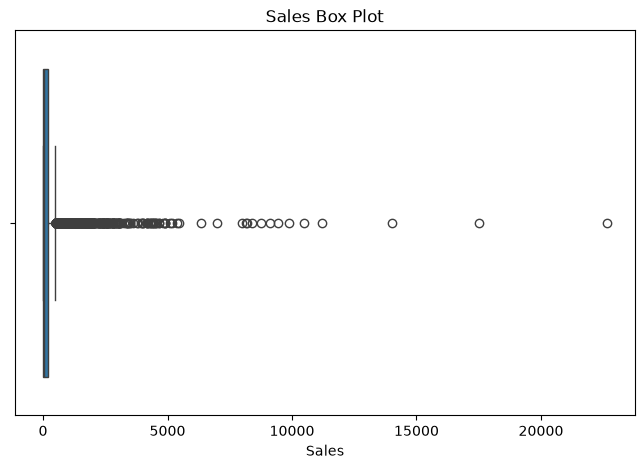

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean["Sales"])

plt.title("Sales Box Plot")

plt.show()

### Observations

* The box plot shows several **high-value outliers** in the Sales column.
* Most sales values are clustered within a relatively small range.
* The large number of outliers indicates that a few expensive orders contribute significantly to total sales.
* The distribution is right-skewed, which is consistent with the histogram.


# Barplot

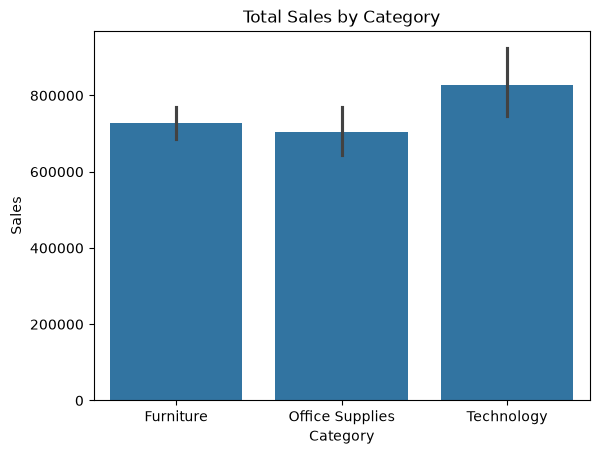

In [26]:
sns.barplot(
    x="Category",
    y="Sales",
    data=df_clean,
    estimator="sum"
)

plt.title("Total Sales by Category")

plt.show()

### Observations

* Sales vary across different product categories.
* The category with the highest bar contributes the largest share of total sales.
* The category with the lowest bar contributes the least to overall revenue.
* The company can prioritize high-performing categories while exploring strategies to improve lower-performing categories.


# Sub-Category-wise Sales

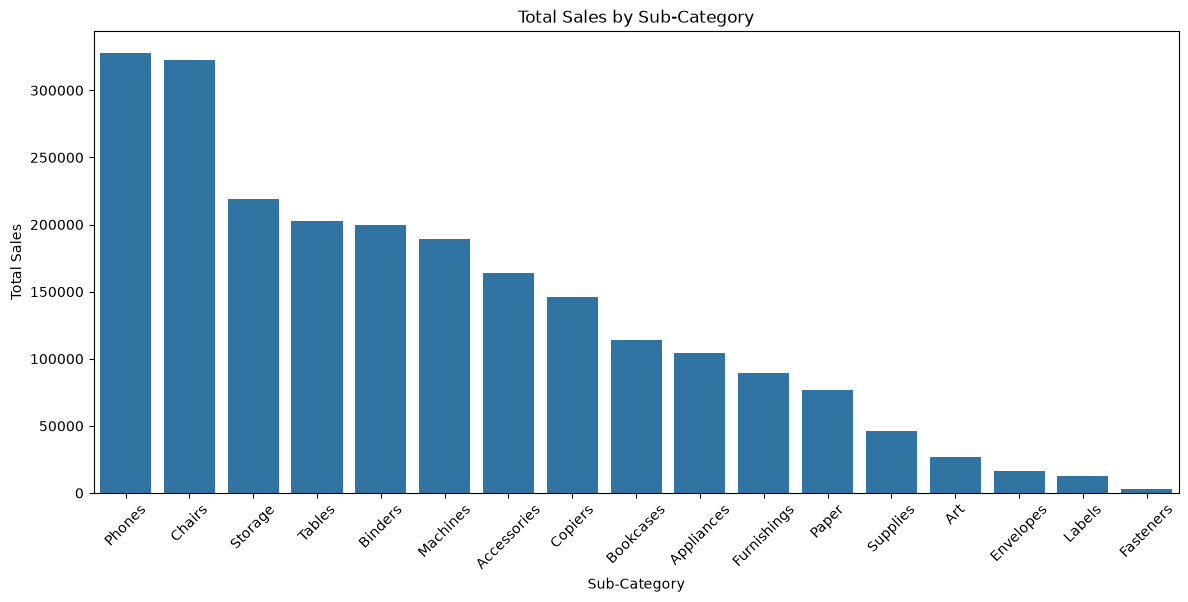

In [28]:
plt.figure(figsize=(14,6))

sub_sales = df_clean.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

sns.barplot(
    x=sub_sales.index,
    y=sub_sales.values
)

plt.xticks(rotation=45)
plt.title("Total Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.show()

### Observations

* Sales differ significantly among product sub-categories.
* A few sub-categories generate a major portion of total sales.
* Some sub-categories contribute relatively little to revenue.
* These results help identify the strongest and weakest product groups for business decision-making.


# Region-wise Sales

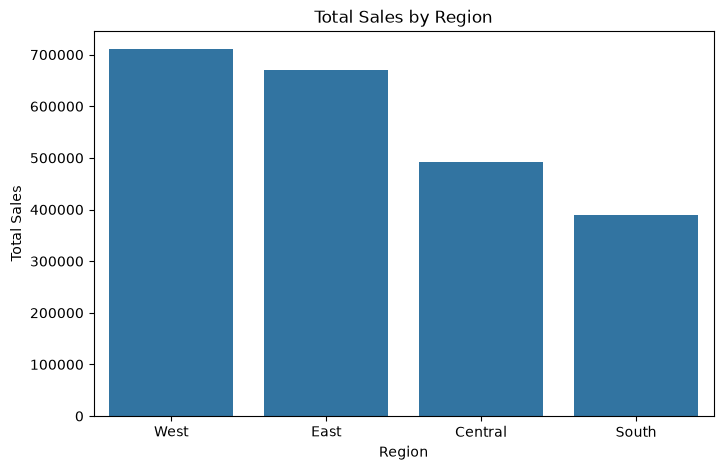

In [29]:
plt.figure(figsize=(8,5))

region_sales = df_clean.groupby("Region")["Sales"].sum().sort_values(ascending=False)

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

### Observations

* Sales performance varies across regions.
* The leading region contributes the highest total sales.
* The lowest-performing region has comparatively smaller sales.
* Regional analysis can help identify markets with strong demand and areas that may require additional business focus.


# Segment-wise Sales

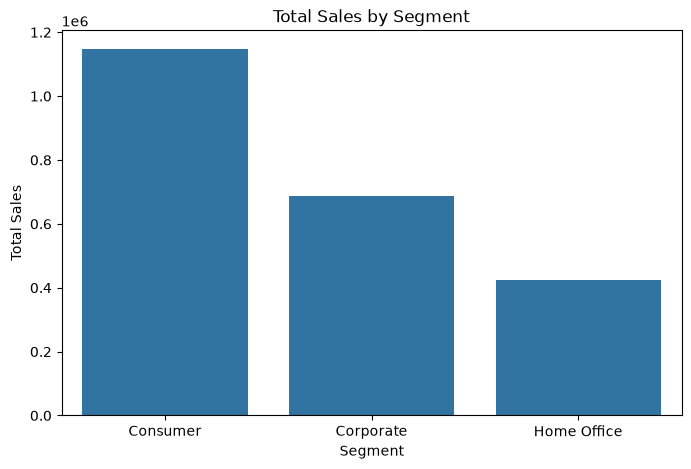

In [30]:
plt.figure(figsize=(8,5))

segment_sales = df_clean.groupby("Segment")["Sales"].sum()

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Total Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.show()

### Observations

* Customer segments contribute differently to total sales.
* The highest-performing segment generates the largest share of revenue.
* The remaining segments also contribute significantly but at different levels.
* Understanding customer segments helps businesses design targeted marketing strategies.


# Ship Mode Analysis

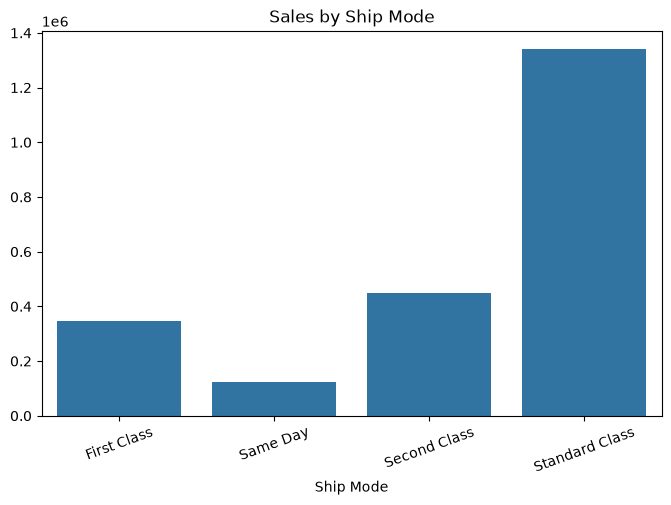

In [31]:
plt.figure(figsize=(8,5))

ship_sales = df_clean.groupby("Ship Mode")["Sales"].sum()

sns.barplot(
    x=ship_sales.index,
    y=ship_sales.values
)

plt.xticks(rotation=20)
plt.title("Sales by Ship Mode")
plt.show()

### Observations

* Sales are distributed across multiple shipping modes.
* One shipping mode is used more frequently and contributes the highest sales.
* Other shipping modes account for smaller portions of total sales.
* This analysis provides insight into customer shipping preferences.


# Monthly Sales Trend

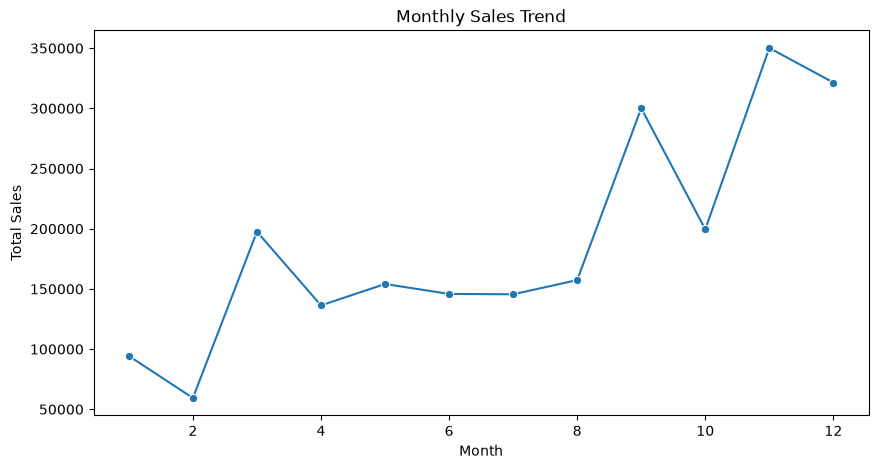

In [32]:
monthly_sales = (
    df_clean.groupby("Month No")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_sales,
    x="Month No",
    y="Sales",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

### Observations

* Monthly sales fluctuate throughout the year.
* Some months experience noticeably higher sales than others.
* Seasonal patterns may influence customer purchasing behavior.
* Businesses can use this trend to improve inventory planning and promotional campaigns.



# Yearly Sales Trend

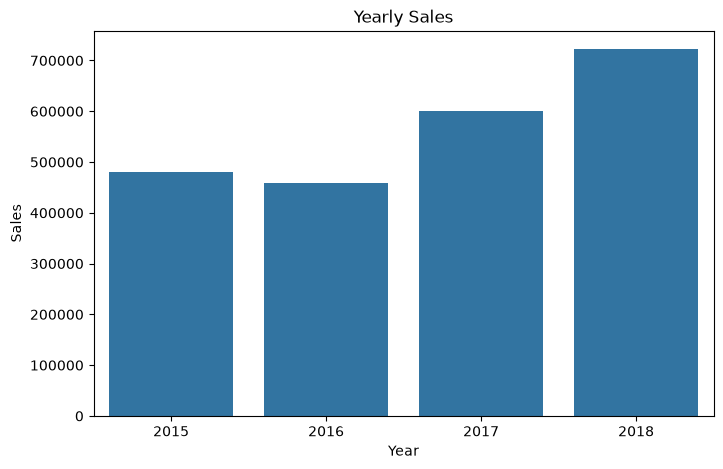

In [33]:
yearly_sales = (
    df_clean.groupby("Year")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=yearly_sales,
    x="Year",
    y="Sales"
)

plt.title("Yearly Sales")
plt.show()

### Observations

* Total sales vary across the four years in the dataset.
* The year with the highest sales reflects the strongest business performance.
* Comparing yearly sales helps evaluate overall business growth over time.
* The trend can support long-term strategic planning.



# Top 10 States

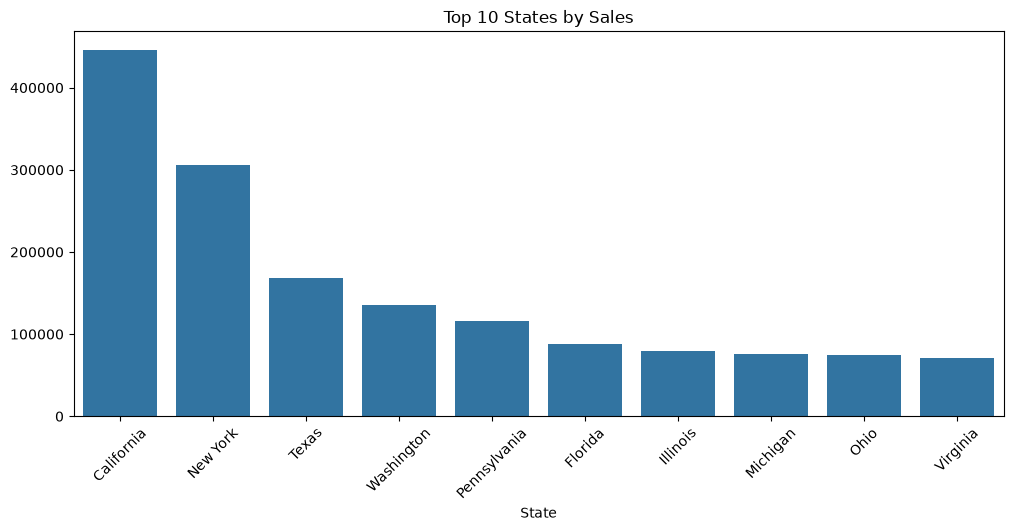

In [34]:
top_states = (
    df_clean.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.xticks(rotation=45)
plt.title("Top 10 States by Sales")
plt.show()

### Observations

* The top 10 states contribute a significant portion of total sales.
* A small number of states generate substantially higher revenue than others.
* These states represent key markets for the business.
* Expanding marketing efforts in high-performing states may further increase sales.


# Top 10 Products

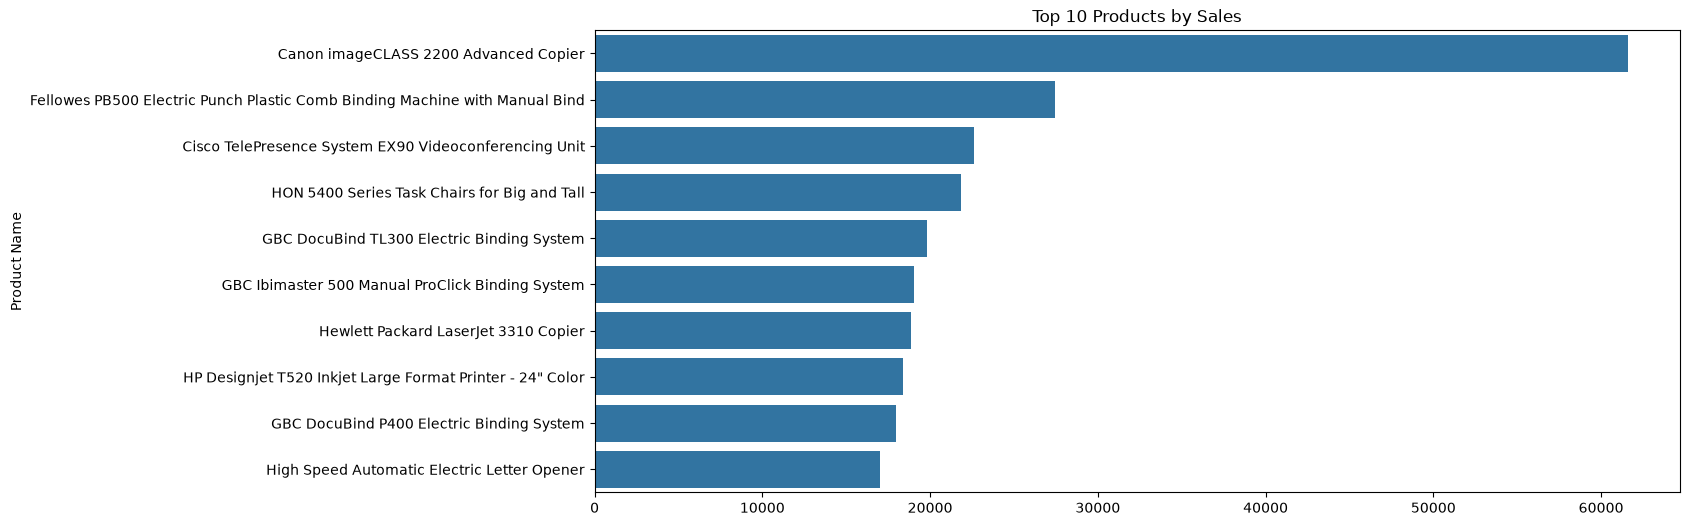

In [35]:
top_products = (
    df_clean.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")
plt.show()

### Observations

* The top-selling products contribute a large share of overall sales.
* A few products dominate total revenue.
* Identifying these products helps prioritize inventory management and promotional strategies.
* Businesses can use this information to focus on their highest-performing products.


## Conclusion

This exploratory data analysis (EDA) provides valuable insights into the retail sales performance of the superstore.

The analysis highlights how sales vary across product categories, customer segments, regions, shipping modes, and time. It also identifies high-performing products and states while revealing the presence of a few high-value sales transactions that influence the overall sales distribution.

Overall, the dataset demonstrates that sales performance is not uniform across all business dimensions. These insights can support data-driven decisions related to inventory management, marketing strategies, regional expansion, and sales planning. The findings from this analysis provide a strong foundation for building dashboards, developing predictive models, and conducting more advanced business analytics in future projects.
